In [19]:
import pandas as pd
import optuna 
import warnings
from scipy.linalg import LinAlgWarning

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, max_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.svm import SVR

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import logging

logging.getLogger('optuna').setLevel(logging.WARNING)

RANDOM_STATE = 42

warnings.filterwarnings('ignore', category=LinAlgWarning)

# Загрузка данных

In [20]:
X_train_dict = {
    'drop_nosc': pd.read_csv('../lab_5/data/drop/X_train_dropnotscaled.csv'),
    'drop_minmax': pd.read_csv('../lab_5/data/drop/X_train_dropminmaxscaler.csv'),
    'drop_robust': pd.read_csv('../lab_5/data/drop/X_train_droprobustscaler.csv'),
    'drop_standart': pd.read_csv('../lab_5/data/drop/X_train_dropstandardscaler.csv'),
    'pca_nosc': pd.read_csv('../lab_5/data/pca/X_train_pcanotscaled.csv'),
    'pca_minmax': pd.read_csv('../lab_5/data/pca/X_train_pcaminmaxscaler.csv'),
    'pca_robust': pd.read_csv('../lab_5/data/pca/X_train_pcarobustscaler.csv'),
    'pca_standart': pd.read_csv('../lab_5/data/pca/X_train_pcastandardscaler.csv')
}

scalers = {
    'drop_minmax': joblib.load('../lab_5/data/drop/drop_scaler_minmax.pkl'),
    'drop_robust': joblib.load('../lab_5/data/drop/drop_scaler_robust.pkl'),
    'drop_standart': joblib.load('../lab_5/data/drop/drop_scaler_standart.pkl'),
    'pca_minmax': joblib.load('../lab_5/data/pca/pca_scaler_minmax.pkl'),
    'pca_robust': joblib.load('../lab_5/data/pca/pca_scaler_robust.pkl'),
    'pca_standart': joblib.load('../lab_5/data/pca/pca_scaler_standart.pkl'),
}

pca_model = joblib.load('../lab_5/data/pca/pca_model.pkl')

y_train = pd.read_csv('../y_train_post.csv')
X_test = pd.read_csv('../X_test.csv')
y_test = pd.read_csv('../y_test.csv')

In [37]:
def create_magic_features(df):
    df_transformed = df.copy()
    df_transformed['Сумма потоков'] = df_transformed['Сила Левого Потока'] + df_transformed['Сила Правого Потока']
    df_transformed['Общая сила потоков'] = df_transformed['Сумма потоков'] + df_transformed['Приток Силы Потока']
    df_transformed['Общая сила ядра'] = df_transformed['Ритм магического ядра'] * df_transformed['Приток Силы Потока']
    df_transformed['Общее давление'] = df_transformed['Приток давления Выдоха Истока'] + df_transformed['Давление выдоха Истока']
    df_transformed['Магическая производительность'] = (df_transformed['Скорость перехода через портал'] / 
                                                     (df_transformed['Эмульсия Истока'] + 1e-8))
    df_transformed['Эффективность ядра'] = (df_transformed['Общая сила ядра'] / 
                                          (df_transformed['Эмульсия Истока'] + 1e-8))
    
    return df_transformed.drop(['Сила Левого Потока', 'Сила Правого Потока', 'Сумма потоков', 'Приток Силы Потока', 'Приток давления Выдоха Истока', 'Давление выдоха Истока'], axis=1)

def drop_other(df):
    return df.drop(['Общая сила ядра', 'Эмульсия Истока', 'Скорость перехода через портал', 'Ритм магического ядра'], axis=1)

def prepare_test_data(data_name, X_test_raw):
    X_test = X_test_raw.copy()
    X_test.fillna(X_test.mean(), inplace=True)
    X_test = create_magic_features(X_test)
    
    if 'drop' in data_name:
        X_test = drop_other(X_test)
        if data_name in scalers:
            scaler = scalers[data_name]
            X_test = scaler.transform(X_test)
            
        return X_test
    
    elif 'pca' in data_name:
        X_test = pca_model.transform(X_test)

        if data_name in scalers:
            scaler = scalers[data_name]
            X_test = scaler.transform(X_test)
            
        return X_test
    
    return X_test.values

# Графики

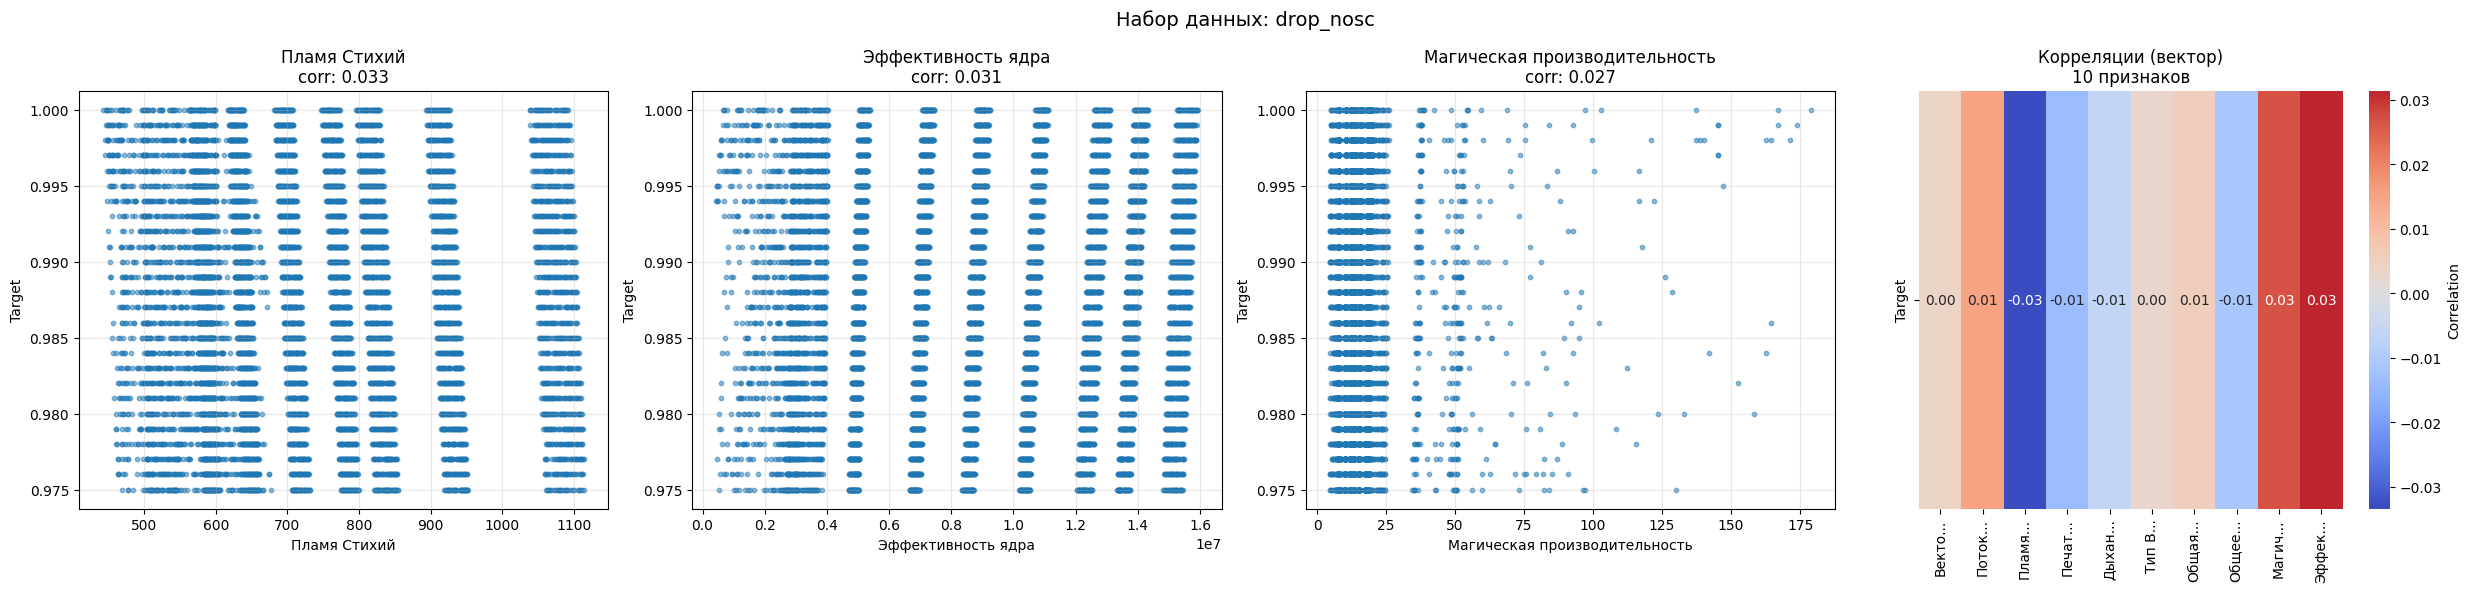

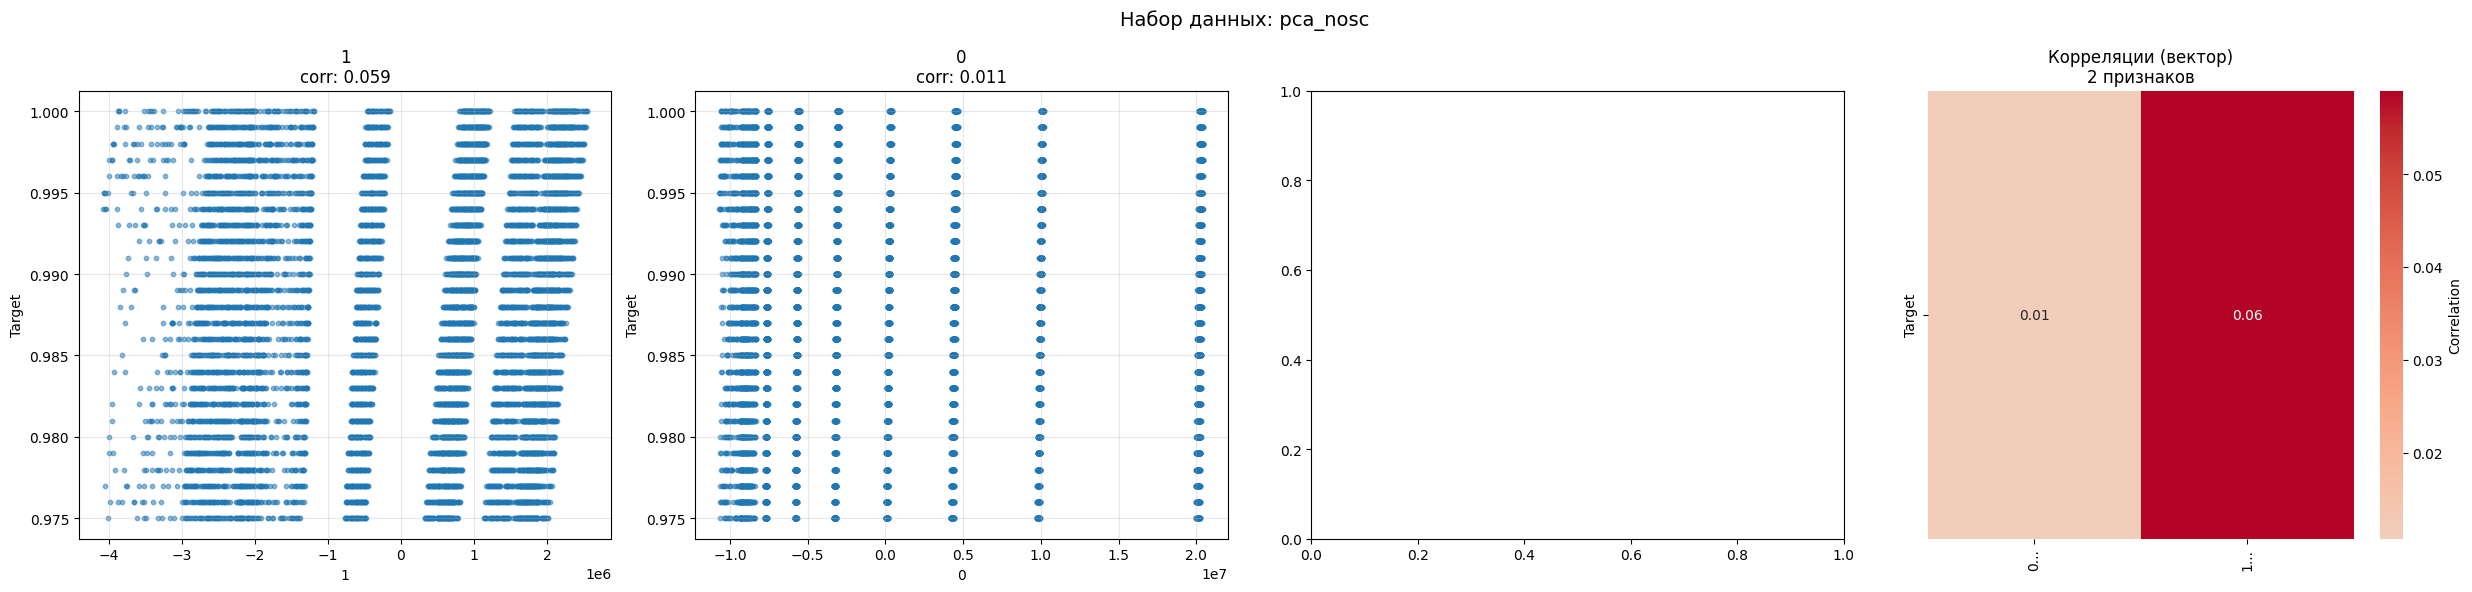

In [12]:
for name in ['drop_nosc', 'pca_nosc']:
    X_data = X_train_dict[name]
    fig, axes = plt.subplots(1, 4, figsize=(25, 6))

    correlations = []
    for col in X_data.columns:
        corr = np.corrcoef(X_data[col], y_train.values.flatten())[0, 1]
        correlations.append((col, abs(corr)))

    correlations.sort(key=lambda x: x[1], reverse=True)
    top_features = correlations[:3]

    for idx, (feature_name, corr_value) in enumerate(top_features):
        axes[idx].scatter(X_data[feature_name], y_train, alpha=0.5, s=10)
        axes[idx].set_xlabel(feature_name)
        axes[idx].set_ylabel('Target')
        axes[idx].set_title(f'{feature_name}\ncorr: {corr_value:.3f}')
        axes[idx].grid(True, alpha=0.3)

    corr_values = []
    feature_names = []
    for col in X_data.columns:
        corr = np.corrcoef(X_data[col], y_train.values.flatten())[0, 1]
        corr_values.append(corr)
        feature_names.append(col[:5]+'...')

    corr_matrix = np.array(corr_values).reshape(1, -1)

    sns.heatmap(corr_matrix, 
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                center=0,
                cbar_kws={'label': 'Correlation'},
                xticklabels=feature_names,
                yticklabels=['Target'],
                ax=axes[3])
    axes[3].set_title(f'Корреляции (вектор)\n{len(feature_names)} признаков')
    axes[3].tick_params(axis='x', rotation=90)
    
    plt.suptitle(f'Набор данных: {name}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Обоснование выбора алгоритмов

| Алгоритм | Сложность обучения | Сложность предсказания | Размер выборки | Размерность признаков | Плюсы | Минусы |
|--------|-------------------|------------------------|----------------|------------------------|-------|--------|
| **Ridge** | Очень быстрая | Мгновенная | Любой | Любая, но лучше при меньшем количестве | - Интерпретируемость<br>- Высокая скорость<br>- Простота реализации<br>- Низкие вычислительные затраты | - Предполагает линейность зависимостей<br>- Чувствительность к мультиколлинеарности<br>- Требует масштабирования данных |
| **AdaBoostRegressor** | Средняя-высокая | Очень быстрая | Средний | Средняя | - Последовательное улучшение качества<br>- Хорошая обобщающая способность<br>- Устойчивость к переобучению | - Чувствительность к выбросам<br>- Требует тщательной настройки гиперпараметров<br>- Может страдать при большом количестве признаков |
| **RandomForestRegressor** | Средняя | Быстрая | Большой-средний | Высокая | - Устойчивость к переобучению<br>- Автоматический отбор важных признаков<br>- Не требует масштабирования данных<br>- Устойчивость к выбросам | - Медленное обучение на очень больших данных<br>- Меньшая интерпретируемость<br>- Может требовать много памяти |
| **SVR** | Высокая-очень высокая | Быстрая | Небольшой-средний | Высокая | - Устойчивость к переобучению<br>- Работа с нелинейными зависимостями через ядра<br>- Эффективность на малых данных<br>- Хорошо работает в высокоразмерных пространствах | - Очень медленное обучение на больших выборках<br>- Требует масштабирования данных<br>- Чувствительность к выбору ядра и параметров |
| **FCNN** | Высокая | Средняя | Большой | Средняя-высокая | - Универсальный аппроксиматор<br>- Моделирование сложных нелинейных зависимостей<br>- Гибкость архитектуры | - Требует больших объемов данных<br>- Сложная настройка гиперпараметров<br>- Долгое обучение<br>- Требует масштабирования данных |

In [13]:
models = {
    'Ridge': Ridge,
    'AdaBoost': AdaBoostRegressor,
    'RandomForest': RandomForestRegressor,
    'SVR': SVR,
    'FCNN': MLPRegressor
}

# Выбор метрик

| Метрика | Формула | Особенности | Когда использовать |
|---------|---------|-------------|-------------------|
| **RMSE** (Root Mean Squared Error) | $\sqrt{\frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2}$ | Чувствительна к выбросам, в тех же единицах измерения что и target | Основная метрика для оптимизации, когда важны большие ошибки |
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum_{i=1}^n\|y_i - \hat{y}_i\|$ | Менее чувствительна к выбросам, интерпретируемая | Когда нужно устойчивое усреднение, важны все ошибки одинаково |
| **R²** (Коэффициент детерминации) | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Безразмерная, показывает долю объясненной дисперсии | Для сравнения моделей между собой, интерпретируемость |
| **MAPE** (Mean Absolute Percentage Error) | $\frac{100\%}{n}\sum_{i=1}^n\left\|\frac{y_i - \hat{y}_i}{y_i}\right\|$ | Процентная ошибка, интуитивно понятная | Когда важны относительные ошибки, target > 0 |
| **Max Error** | $\max(\|y_i - \hat{y}_i\|)$ | Наибольшая ошибка по выборке | Для контроля наихудшего случая, в safety-critical системах |

**Целевая метрика RMSE:**
1. **Чувствительность к большим ошибкам** - RMSE квадратично штрафует большие отклонения, что важно для предотвращения катастрофических ошибок
2. **Единицы измерения** - Выражается в тех же единицах что и target, что делает её интерпретируемой
3. **Дифференцируемость** - Квадратичная функция гладкая и дифференцируемая, что хорошо для градиентных методов оптимизации
4. **Распространенность** - Стандартная метрика в задачах регрессии, позволяет сравнивать с другими исследованиями
5. **Баланс** - Более сбалансирована чем R² (который может быть обманчивым) и менее чувствительна к выбросам чем чистое MSE

**Почему не другие метрики как основная:**
- **MAE** - Не дифференцируема в точке 0, менее чувствительна к критическим ошибкам
- **R²** - Может быть обманчивым при нелинейных зависимостях, плохо интерпретируется при отрицательных значениях
- **MAPE** - Не определен при нулевых значениях target, может давать бесконечные значения
- **Max Error** - Слишком чувствительна к единичным выбросам

In [14]:
metrics = {
    'RMSE': lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    'MAE': mean_absolute_error,
    'R2': r2_score,
    'MAPE': mean_absolute_percentage_error,
    'MaxError': max_error
}

# Определение словарей гиперпараметров

In [15]:
param_grids = {
    'Ridge': {
        'alpha': {
            'type': 'float',
            'low': 0.01,
            'high': 100,
            'log': True
        }
    },
    
    'AdaBoost': {
        'n_estimators': {
            'type': 'int',
            'low': 50,
            'high': 300
        },
        'learning_rate': {
            'type': 'float',
            'low': 0.05,
            'high': 1.0
        }
    },
    
    'RandomForest': {
        'n_estimators': {
            'type': 'int',
            'low': 100,
            'high': 400
        },
        'max_depth': {
            'type': 'int',
            'low': 5,
            'high': 30
        },
        'min_samples_split': {
            'type': 'int',
            'low': 2,
            'high': 10
        }
    },
    
    'SVR': {
        'C': {
            'type': 'float',
            'low': 0.1,
            'high': 10,
            'log': True
        },
        'epsilon': {
            'type': 'float',
            'low': 0.05,
            'high': 0.5
        }
    },
    
    'FCNN': {
        'hidden_layer_sizes': {
            'type': 'categorical',
            'values': [(50,), (100,), (50, 25)]
        },
        'alpha': {
            'type': 'float',
            'low': 0.0001,
            'high': 0.01,
            'log': True
        },
        'learning_rate_init': {
            'type': 'float',
            'low': 0.001,
            'high': 0.1
        }
    }
}

# Подбор гиперпараметров для моделей

In [16]:
def gen_objective(estimator_class, grid, X_train, y_train, X_test, y_test, criterion, /, cv=False, **kwargs):
    def objective(trial):
        params = {}
        for param_name, param_config in grid.items():
            if param_config['type'] == 'categorical':
                params[param_name] = trial.suggest_categorical(
                    param_name, param_config['values']
                )
            elif param_config['type'] == 'int':
                params[param_name] = trial.suggest_int(
                    param_name, 
                    param_config['low'], 
                    param_config['high']
                )
            elif param_config['type'] == 'float':
                if param_config.get('log', False):
                    params[param_name] = trial.suggest_float(
                        param_name, 
                        param_config['low'], 
                        param_config['high'], 
                        log=True
                    )
                else:
                    params[param_name] = trial.suggest_float(
                        param_name, 
                        param_config['low'], 
                        param_config['high']
                    )
        
        model = estimator_class(**params, **kwargs)
        
        if cv:
            scores = []
            for train_idx, val_idx in KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE).split(X_train):
                X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                
                model.fit(X_fold_train, y_fold_train)
                y_pred = model.predict(X_fold_val)
                score = criterion(y_fold_val, y_pred)
                scores.append(score)
            
            result = np.mean(scores)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            result = criterion(y_test, y_pred)
        
        return result
    
    return objective

In [17]:
best_models = {}
criterion = metrics['RMSE']
N_FOLDS = 5
N_TRIALS = 25

for model_name, model_class in models.items():
    for data_name, X_data in X_train_dict.items():
        print(f"Оптимизация: {model_name} на данных {data_name}")

        objective = gen_objective(
            model_class,
            param_grids[model_name],
            X_data,
            y_train,
            None,
            None,
            criterion,
            cv=N_FOLDS
        )

        study = optuna.create_study(
            direction='minimize',
            study_name=f"{model_name}_{data_name}",
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
        )
        
        study.optimize(objective, n_trials=N_TRIALS, n_jobs=-1, show_progress_bar=True)

        key = f"{model_name}_{data_name}"
        best_models[key] = {
            'best_params': study.best_params,
            'best_value': study.best_value,
            'model_class': model_class,
            'data_name': data_name,
            'study': study
        }
        
        print(f"Лучшее значение RMSE: {study.best_value:.4f}")
        print(f"Лучшие параметры: {study.best_params}")

Оптимизация: Ridge на данных drop_nosc


  0%|          | 0/25 [00:00<?, ?it/s]

Лучшее значение RMSE: 0.0051
Лучшие параметры: {'alpha': 0.012799714548567962}
Оптимизация: Ridge на данных drop_minmax


  0%|          | 0/25 [00:00<?, ?it/s]

Лучшее значение RMSE: 0.0051
Лучшие параметры: {'alpha': 0.015591049562875315}
Оптимизация: Ridge на данных drop_robust


...

e:\Python\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  0%|          | 0/25 [00:00<?, ?it/s]

e:\Python\venv\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  warnings.warn(message)
e:\Python\venv\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  warnings.warn(message)
e:\Python\venv\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 25) which is of type tuple.
  warnings.warn(message)
e:\Python\venv\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type 

Лучшее значение RMSE: 0.0065
Лучшие параметры: {'hidden_layer_sizes': (100,), 'alpha': 0.0007393408758776427, 'learning_rate_init': 0.0489849842643471}


e:\Python\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [18]:
trained_models = {}

for key, study_info in best_models.items():
    model_name = key.split('_')[0]
    data_name = '_'.join(key.split('_')[1:])
    
    print(f"Обучение {key}...")

    model_class = models[model_name]
    best_params = study_info['best_params']
    X_train_data = X_train_dict[data_name]

    model = model_class(**best_params)
    model.fit(X_train_data, y_train.values.ravel())

    trained_models[key] = {
        'model': model,
        'params': best_params,
        'data_name': data_name,
        'model_name': model_name,
        'train_score': study_info['best_value']
    }

Обучение Ridge_drop_nosc...
Обучение Ridge_drop_minmax...
Обучение Ridge_drop_robust...
Обучение Ridge_drop_standart...
Обучение Ridge_pca_nosc...
Обучение Ridge_pca_minmax...
Обучение Ridge_pca_robust...
Обучение Ridge_pca_standart...
Обучение AdaBoost_drop_nosc...
Обучение AdaBoost_drop_minmax...
Обучение AdaBoost_drop_robust...
Обучение AdaBoost_drop_standart...
Обучение AdaBoost_pca_nosc...
Обучение AdaBoost_pca_minmax...
Обучение AdaBoost_pca_robust...
Обучение AdaBoost_pca_standart...
Обучение RandomForest_drop_nosc...
Обучение RandomForest_drop_minmax...
Обучение RandomForest_drop_robust...
Обучение RandomForest_drop_standart...
Обучение RandomForest_pca_nosc...
Обучение RandomForest_pca_minmax...
Обучение RandomForest_pca_robust...
Обучение RandomForest_pca_standart...
Обучение SVR_drop_nosc...
Обучение SVR_drop_minmax...
Обучение SVR_drop_robust...
Обучение SVR_drop_standart...
Обучение SVR_pca_nosc...
Обучение SVR_pca_minmax...
Обучение SVR_pca_robust...
Обучение SVR_pca_stan

e:\Python\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Обучение FCNN_pca_minmax...
Обучение FCNN_pca_robust...
Обучение FCNN_pca_standart...


In [23]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3581 entries, 0 to 3580
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     3581 non-null   float64
 1   Скорость перехода через портал  3215 non-null   float64
 2   Приток Силы Потока              3581 non-null   float64
 3   Ритм магического ядра           3581 non-null   float64
 4   Поток Энергий                   3581 non-null   float64
 5   Сила Левого Потока              3581 non-null   float64
 6   Сила Правого Потока             3581 non-null   float64
 7   Пламя Стихий                    3581 non-null   float64
 8   Приток давления Выдоха Истока   3581 non-null   float64
 9   Давление выдоха Истока          3581 non-null   float64
 10  Печать Чародея                  3581 non-null   float64
 11  Эмульсия Истока                 3581 non-null   float64
 12  Дыхание Истока                  35

In [43]:
results = []

for key, model_info in trained_models.items():
    X_test_prepared = prepare_test_data(model_info['data_name'], X_test)

    y_pred = model_info['model'].predict(X_test_prepared)

    result = {'model': key}
    for name, func in metrics.items():
        result[name] = round(func(y_test.values.ravel(), y_pred), 3)
    
    results.append(result)

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

e:\Python\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Python\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Python\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Python\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Python\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
e:\Python\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was

,model,RMSE,MAE,R2,MAPE,MaxError
19,RandomForest_drop_standart,0.001,0.000,0.993,0.000,0.008
18,RandomForest_drop_robust,0.001,0.000,0.992,0.000,0.008
17,RandomForest_drop_minmax,0.001,0.000,0.993,0.000,0.008
16,RandomForest_drop_nosc,0.001,0.000,0.993,0.000,0.008
23,RandomForest_pca_standart,0.003,0.002,0.833,0.002,0.020
22,RandomForest_pca_robust,0.003,0.002,0.829,0.002,0.019
21,RandomForest_pca_minmax,0.003,0.002,0.834,0.002,0.020
20,RandomForest_pca_nosc,0.003,0.002,0.834,0.002,0.020
0,Ridge_drop_nosc,0.005,0.004,0.545,0.004,0.018
1,Ridge_drop_minmax,0.005,0.004,0.545,0.004,0.018


In [44]:
joblib.dump(trained_models, 'all_models.pkl')

['all_models.pkl']

**Аномальные результаты (очевидно неадекватные модели):**
**FCNN_drop_nosc**:
- R² = -22030 (абсурдно отрицательный)
- RMSE = 1.118 (на порядки хуже)
- **Причина**: нейросеть без масштабирования данных

**FCNN_pca_nosc**:
- R² = -1.4M (катастрофически плохо)
- MaxError = 99.943 (огромная ошибка)
- **Причина**: нейросеть на PCA без масштабирования

**Правдоподобные результаты (полу-адекватные модели):**
**RandomForest на drop данных**:
- Все 4 варианта: RMSE=0.001, R²=0.993
- Согласованные результаты по всем скейлерам
- Стабильные, предсказуемые

**Ridge на drop данных**:
- RMSE=0.005, R²=0.545 (умеренно хорошо)
- Все скейлеры дают одинаковый результат

**Признаки возможного переобучения:**
**RandomForest на PCA данных**:
- RMSE=0.003 vs 0.001 на drop (хуже в 3 раза)
- R²=0.83 vs 0.993 (значительно хуже)
- **Причина**: PCA удалил важные для RF признаки

**Все SVR модели**:
- R² ≈ -0.001 (практически нулевой)
- **Причина**: мало данных для SVR

**FCNN на масштабированных данных**:
- RMSE=0.006-0.012 (плохо для нейросети)
- R²=0.15-0.35 (очень низкий)
- **Причина**: недостаточно данных или плохая архитектура

**Вывод:**
- **Лучшие**: RandomForest_drop_* (стабильно отлично)
- **Худшие**: FCNN без масштабирования (катастрофа)
- **Средние**: Ridge (приемлемо), остальные (плохо)
- **Переобучения нет**: RandomForest одинаково хорошо на всех скейлерах